In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec



# ==========================================
# 1. Set local file path
# ==========================================

# Path to the Downloads folder
base_path = "/Users/li0o0sun/projects/Projectwork2026/data"
file_name = "09_filtered_all_data.pkl"
full_path = os.path.join(base_path, file_name)


def load_local_data(path):
    """
    Load EMG dataset from a local pickle file,
    perform memory optimization, detect bad channels,
    and convert gait phase into circular coordinates.
    """

    # Check whether file exists
    if not os.path.exists(path):
        print(f"❌ File not found: {path}")
        print("Please check the filename or confirm the file is in the Downloads folder.")
        return None

    print(f"📂 Loading data from: {path} ...")

    try:
        # ------------------------------------------
        # Load pickle file into pandas DataFrame
        # ------------------------------------------
        df = pd.read_pickle(path)

        # ------------------------------------------
        # Memory optimization
        # Convert float64 columns to float32
        # (reduces memory usage for large datasets)
        # ------------------------------------------
        float_cols = df.select_dtypes(include=['float64']).columns
        df[float_cols] = df[float_cols].astype('float32')

        print("✅ Data loaded successfully!")
        print(f"📊 Shape: {df.shape[0]} rows x {df.shape[1]} columns")

        # ------------------------------------------
        # Bad channel detection
        # Method:
        # 1. Compute median power of each EMG channel
        # 2. Calculate Z-score across channels
        # 3. Channels beyond ±3 std are marked as bad
        # ------------------------------------------
        emg_cols = [
            c for c in df.columns
            if 'Ch' in str(c) and '(' in str(c) and 'Ankle' not in str(c)
        ]

        if emg_cols:
            # Median power of each channel
            channel_medians = (df[emg_cols] ** 2).median()

            # Z-score normalization
            z_scores = (
                channel_medians - channel_medians.mean()
            ) / (channel_medians.std() + 1e-6)

            # Detect abnormal channels
            bad_channels = z_scores[abs(z_scores) > 3].index.tolist()

            if bad_channels:
                print(f"🚩 Found {len(bad_channels)} bad channels: {bad_channels}")
            else:
                print("✨ Signal quality looks good. No abnormal channels detected.")

        # ------------------------------------------
        # Convert gait phase (0–100%) into circular coordinates
        # This avoids discontinuity between 0% and 100%
        # ------------------------------------------
        if 'Activity %' in df.columns:
            theta = (df['Activity %'] / 100) * 2 * np.pi

            df['phase_x'] = np.cos(theta)
            df['phase_y'] = np.sin(theta)

            print("✅ Gait phase converted to circular coordinates (cos, sin).")

        return df

    except Exception as e:
        print(f"❌ Loading failed: {e}")
        return None


# Execute loading
df = load_local_data(full_path)


📂 Loading data from: /Users/li0o0sun/projects/Projectwork2026/data/09_filtered_all_data.pkl ...
✅ Data loaded successfully!
📊 Shape: 1488351 rows x 162 columns

--- Sample of raw dtypes ---
object    162
Name: count, dtype: int64

--- First few values of first 5 columns ---
  Timestamp: nan (type=<class 'float'>)
  Activity: walk (type=<class 'str'>)
  Gait: 0.0 (type=<class 'numpy.float64'>)
  Reps: 0.0 (type=<class 'numpy.float64'>)
  EMG_TA_CH_0: -0.004679847845818829 (type=<class 'float'>)


/var/folders/41/3ls148sj6f53v3y6sffbf_kc0000gn/T/ipykernel_6066/176162176.py:109: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_converted = df.apply(pd.to_numeric, errors='ignore')



After conversion: 161 numeric columns


In [5]:
# Force proper dtype inference on all columns
df = df.infer_objects()  # first pass — fast

# Second pass — explicitly coerce remaining object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

numeric_df = df.select_dtypes(include=[np.number])
categorical_df = df.select_dtypes(exclude=[np.number])

print(f"\n✅ Number of numeric columns: {numeric_df.shape[1]}")
print(f"✅ Number of categorical/text columns: {categorical_df.shape[1]}")

/var/folders/41/3ls148sj6f53v3y6sffbf_kc0000gn/T/ipykernel_6066/770494198.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')



✅ Number of numeric columns: 161
✅ Number of categorical/text columns: 1



--- Actual Column Names ---
['Timestamp', 'Activity', 'Gait', 'Reps', 'EMG_TA_CH_0', 'EMG_TA_CH_1', 'EMG_TA_CH_2', 'EMG_TA_CH_3', 'EMG_TA_CH_4', 'EMG_TA_CH_5', 'EMG_TA_CH_6', 'EMG_TA_CH_7', 'EMG_TA_CH_8', 'EMG_TA_CH_9', 'EMG_TA_CH_10', 'EMG_TA_CH_11', 'EMG_TA_CH_12', 'EMG_TA_CH_13', 'EMG_TA_CH_14', 'EMG_TA_CH_15', 'EMG_TA_CH_16', 'EMG_TA_CH_17', 'EMG_TA_CH_18', 'EMG_TA_CH_19', 'EMG_TA_CH_20', 'EMG_TA_CH_21', 'EMG_TA_CH_22', 'EMG_TA_CH_23', 'EMG_TA_CH_24', 'EMG_TA_CH_25', 'EMG_TA_CH_26', 'EMG_TA_CH_27', 'EMG_TA_CH_28', 'EMG_TA_CH_29', 'EMG_TA_CH_30', 'EMG_TA_CH_31', 'EMG_TA_CH_32', 'EMG_TA_CH_33', 'EMG_TA_CH_34', 'EMG_TA_CH_35', 'EMG_TA_CH_36', 'EMG_TA_CH_37', 'EMG_TA_CH_38', 'EMG_TA_CH_39', 'EMG_TA_CH_40', 'EMG_TA_CH_41', 'EMG_TA_CH_42', 'EMG_TA_CH_43', 'EMG_TA_CH_44', 'EMG_TA_CH_45', 'EMG_TA_CH_46', 'EMG_TA_CH_47', 'EMG_TA_CH_48', 'EMG_TA_CH_49', 'EMG_TA_CH_50', 'EMG_TA_CH_51', 'EMG_TA_CH_52', 'EMG_TA_CH_53', 'EMG_TA_CH_54', 'EMG_TA_CH_55', 'EMG_TA_CH_56', 'EMG_TA_CH_57', 'EMG_TA_CH_

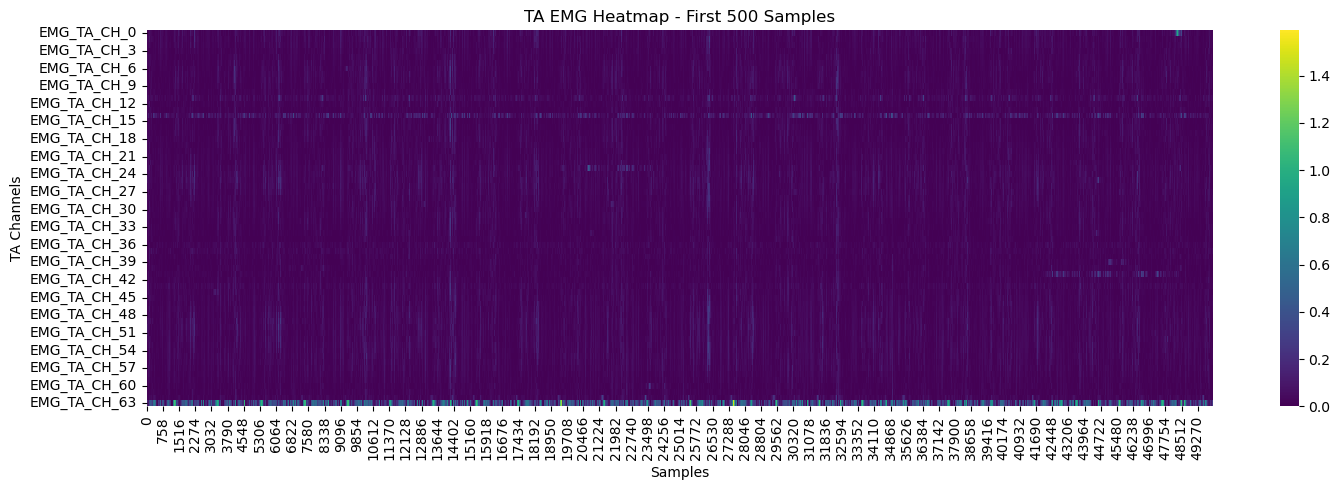

In [7]:
# ----------------------------
# 1. Print column names
# ----------------------------
print("\n--- Actual Column Names ---")
print(df.columns.tolist())

# ----------------------------
# 2. Separate numeric & categorical
# ----------------------------
numeric_df = df.select_dtypes(include=[np.number])
categorical_df = df.select_dtypes(exclude=[np.number])

print(f"\n✅ Number of numeric columns: {numeric_df.shape[1]}")
print(f"✅ Number of categorical/text columns: {categorical_df.shape[1]}")

# ----------------------------
# 3. Label inspection
# ----------------------------
label_cols = ['Activity', 'Gait', 'Reps']

print("\n--- Label Column Preview ---")
print(df[label_cols].head())

for col in label_cols:
    print(f"\n--- Distribution of {col} ---")
    print(df[col].value_counts())

# ----------------------------
# 4. Detect EMG columns properly
# ----------------------------
emg_ta_cols = [c for c in df.columns if c.startswith('EMG_TA')]
emg_gm_cols = [c for c in df.columns if c.startswith('EMG_GM')]

print(f"\n✅ TA channels detected: {len(emg_ta_cols)}")
print(f"✅ GM channels detected: {len(emg_gm_cols)}")

# ----------------------------
# 5. Basic sanity check
# ----------------------------
if len(emg_ta_cols) != 64 or len(emg_gm_cols) != 64:
    print("⚠️ Warning: EMG channels are not exactly 64 per muscle")

# ----------------------------
# 6. Plot EMG heatmap (TA example)
# ----------------------------
if len(emg_ta_cols) > 0:

    plt.figure(figsize=(15, 5))

    ta_data = df[emg_ta_cols].iloc[:50000].abs().T

    sns.heatmap(
        ta_data,
        cmap='viridis'
    )

    plt.title("TA EMG Heatmap - First 500 Samples")
    plt.xlabel("Samples")
    plt.ylabel("TA Channels")
    plt.tight_layout()
    plt.show()

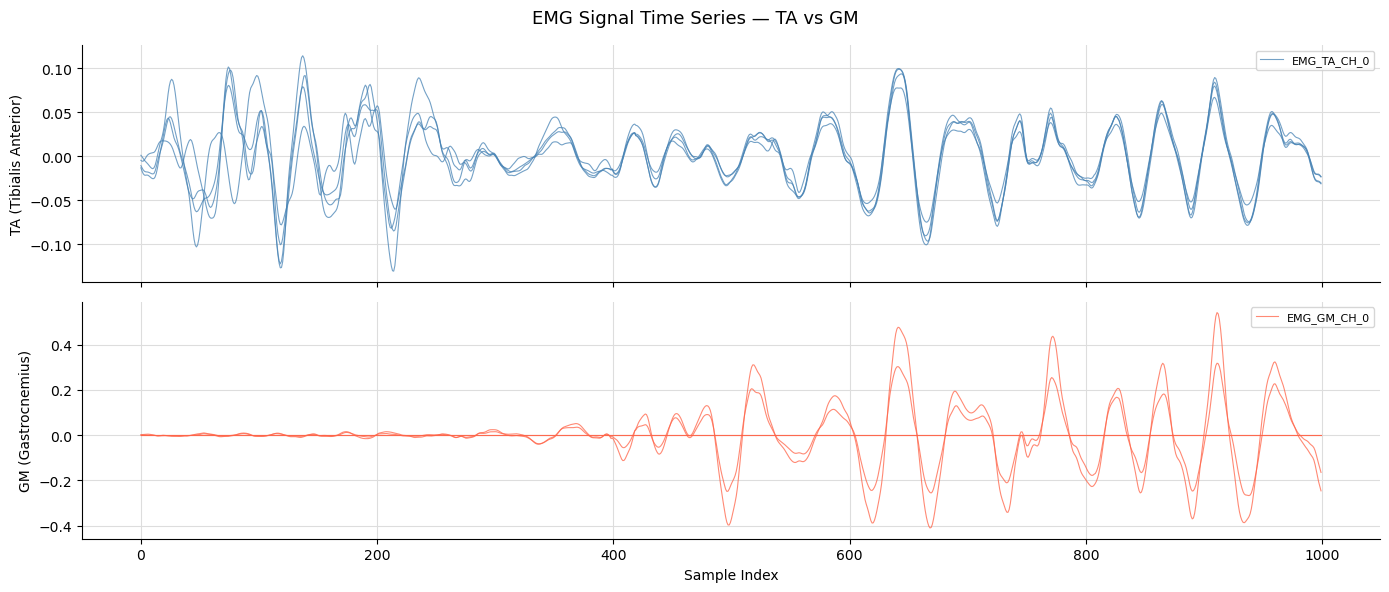

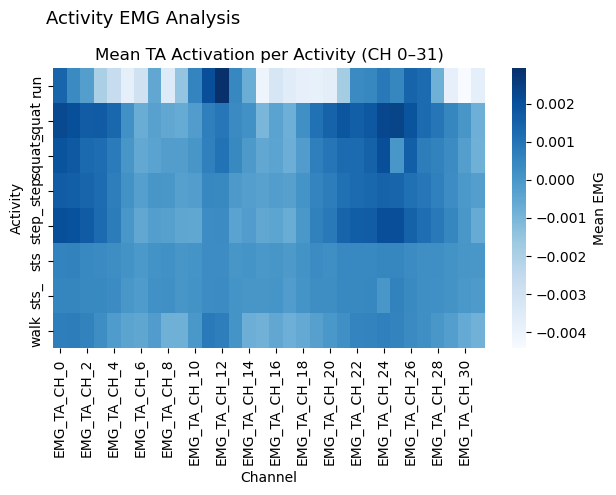

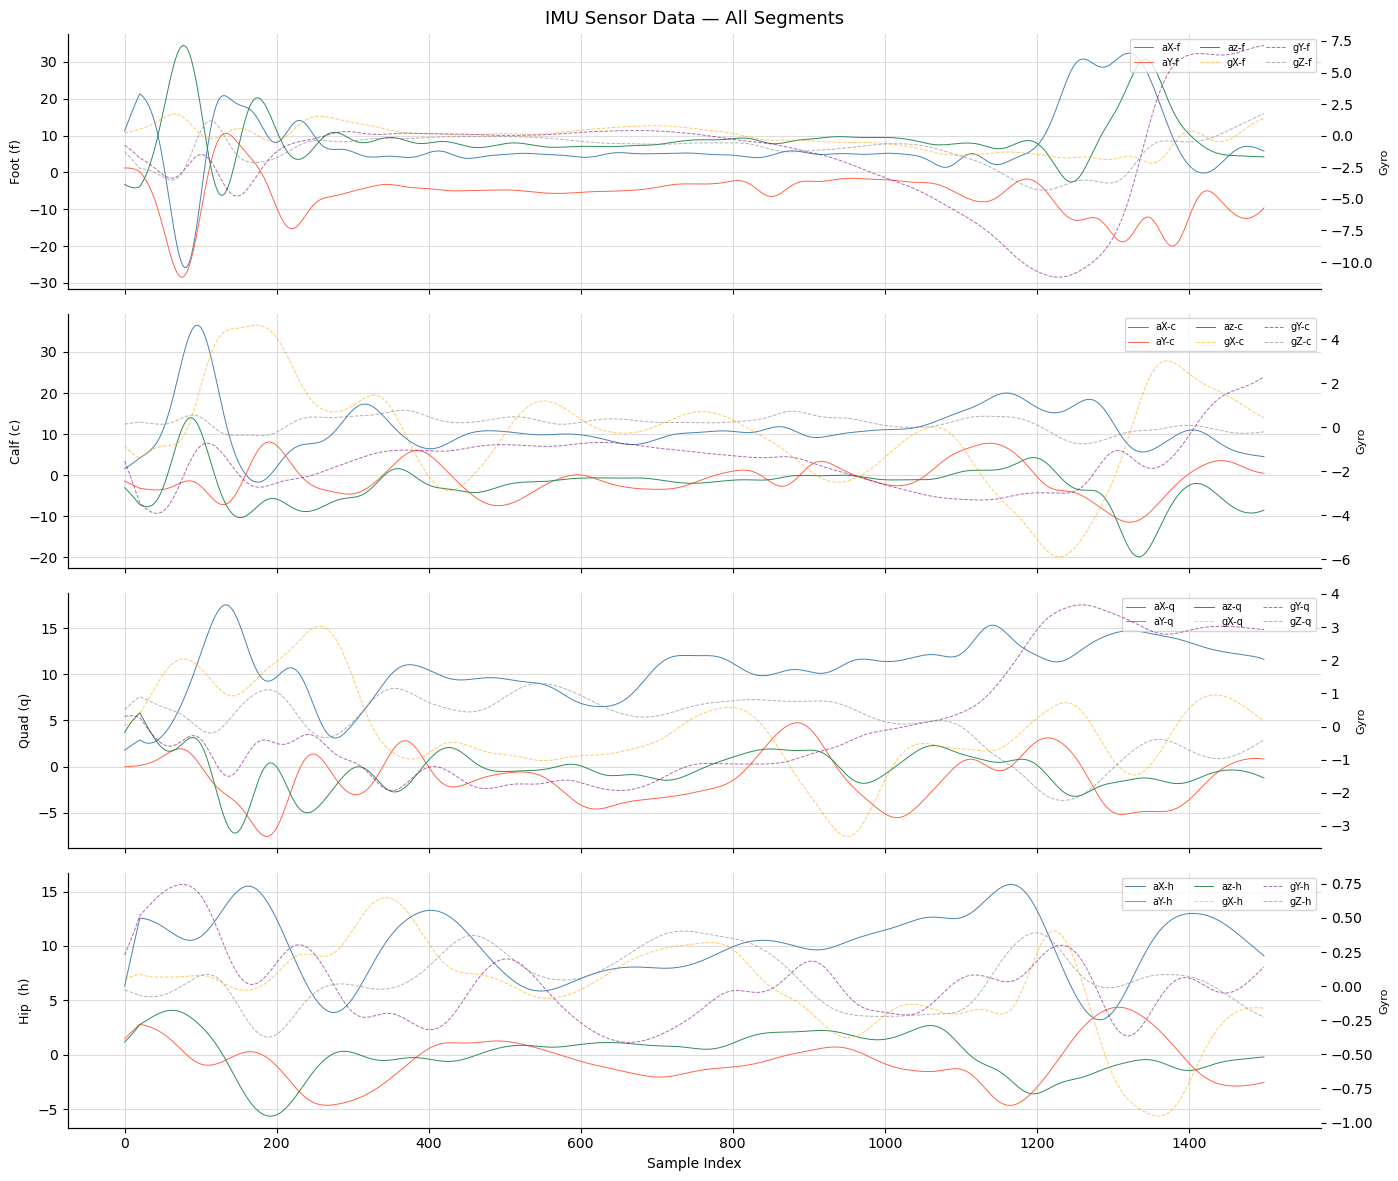

In [18]:


plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   'black',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'text.color':       'black',
    'grid.color':       '#dddddd',
    'grid.alpha':       1.0,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

emg_ta_cols = [c for c in df.columns if c.startswith('EMG_TA_CH')]
emg_gm_cols = [c for c in df.columns if c.startswith('EMG_GM_CH')]
activities  = df['Activity'].unique()


# ══════════════════════════════════════════════════════════════
# p1：EMG Signal Time Series
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle('EMG Signal Time Series — TA vs GM', fontsize=13)

n = 1000
for i, (cols, label, color) in enumerate([
    (emg_ta_cols[:4], 'TA (Tibialis Anterior)', 'steelblue'),
    (emg_gm_cols[:4], 'GM (Gastrocnemius)',     'tomato'),
]):
    ax = axes[i]
    for j, col in enumerate(cols):
        ax.plot(df[col].iloc[:n].values,
                alpha=0.75, linewidth=0.8, color=color,
                label=col if j == 0 else '_nolegend_')
    ax.set_ylabel(label, fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True)

axes[1].set_xlabel('Sample Index')
plt.tight_layout()
# plt.savefig('fig1_emg_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════
# p2：Activity EMG Analysis
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6])

ax_heat = fig.add_subplot(gs[1])
act_emg = df.groupby('Activity')[emg_ta_cols[:32]].mean()
sns.heatmap(act_emg, ax=ax_heat, cmap='Blues',
            cbar_kws={'label': 'Mean EMG'},
            linewidths=0, yticklabels=act_emg.index)
ax_heat.set_title('Mean TA Activation per Activity (CH 0–31)')
ax_heat.set_xlabel('Channel')
ax_heat.set_ylabel('Activity')

plt.suptitle('Activity EMG Analysis', fontsize=13)
plt.tight_layout()
# plt.savefig('fig2_gait_phase.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════
# p3：IMU sensor temporal
# ══════════════════════════════════════════════════════════════
imu_groups = {
    'Foot (f)': ['aX-f','aY-f','az-f','gX-f','gY-f','gZ-f'],
    'Calf (c)': ['aX-c','aY-c','az-c','gX-c','gY-c','gZ-c'],
    'Quad (q)': ['aX-q','aY-q','az-q','gX-q','gY-q','gZ-q'],
    'Hip  (h)': ['aX-h','aY-h','az-h','gX-h','gY-h','gZ-h'],
}
valid_groups = {k: [c for c in v if c in df.columns] for k, v in imu_groups.items()}
valid_groups = {k: v for k, v in valid_groups.items() if v}

n_groups = len(valid_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(14, 3 * n_groups), sharex=True)
fig.suptitle('IMU Sensor Data — All Segments', fontsize=13)
if n_groups == 1:
    axes = [axes]

n = 1500
acc_colors = ['steelblue', 'tomato', 'seagreen']
gyr_colors = ['orange',    'purple',  'gray']

for ax, (seg, cols) in zip(axes, valid_groups.items()):
    acc_cols = [c for c in cols if c.startswith('a')]
    gyr_cols = [c for c in cols if c.startswith('g')]
    for c, color in zip(acc_cols, acc_colors):
        ax.plot(df[c].iloc[:n].values, linewidth=0.7, color=color, label=c)
    ax2 = ax.twinx()
    for c, color in zip(gyr_cols, gyr_colors):
        ax2.plot(df[c].iloc[:n].values, linewidth=0.7, alpha=0.6,
                 linestyle='--', color=color, label=c)
    ax2.set_ylabel('Gyro', fontsize=8)
    ax.set_ylabel(seg, fontsize=9)
    ax.grid(True)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              loc='upper right', fontsize=7, ncol=3)

axes[-1].set_xlabel('Sample Index')
plt.tight_layout()
# plt.savefig('fig3_imu.png', dpi=150, bbox_inches='tight')
plt.show()
